# Case Study: The 2022 Inflation Shock

Focused analysis of RBI communication and market response through the 2022 tightening cycle (January 2022 - March 2023), testing whether communication tone moved markets ahead of the corresponding policy action.

## Step 0 — Path setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\hp\Desktop\rbi-sentiment-market-forecast


## Step 1 — Load data for the case-study window

In [2]:
from paths import GSEC_CSV, SENTIMENT_CSV, MERGED_CSV, FIGURES_DIR

CASE_START = "2022-01-01"
CASE_END = "2023-03-31"

gsec_raw = pd.read_csv(GSEC_CSV)
gsec_raw["Date"] = pd.to_datetime(gsec_raw["Date"], dayfirst=True, errors="coerce")
gsec_raw["Price"] = gsec_raw["Price"].astype(str).str.replace(",", "", regex=False).astype(float)
gsec_series = gsec_raw.dropna(subset=["Date"]).sort_values("Date").set_index("Date")["Price"]
gsec_window = gsec_series[CASE_START:CASE_END]

sentiment = pd.read_csv(SENTIMENT_CSV, parse_dates=["listed_date"])
case_sentiment = sentiment[(sentiment["listed_date"] >= CASE_START) & (sentiment["listed_date"] <= CASE_END)].sort_values("listed_date")

merged = pd.read_csv(MERGED_CSV, parse_dates=["listed_date"])
case_merged = merged[(merged["listed_date"] >= CASE_START) & (merged["listed_date"] <= CASE_END)].sort_values("listed_date")

print(f"{len(gsec_window)} daily yield observations, {len(case_sentiment)} statements, {len(case_merged)} resolutions in window")

305 daily yield observations, 24 statements, 8 resolutions in window


## Step 2 — Full chronology

Every statement in the window, by sentiment score and document type.

In [3]:
print(case_sentiment[["listed_date", "doc_type", "lexicon_score_x1000", "finbert_score"]].to_string())

    listed_date            doc_type  lexicon_score_x1000  finbert_score
77   2022-02-10  governor_statement            -0.887311       0.230246
78   2022-02-10          resolution            -1.221001       0.097431
79   2022-02-24             minutes            -1.741294       0.019401
80   2022-04-08          resolution            -1.948052       0.107184
81   2022-04-08  governor_statement            -0.290360       0.137519
82   2022-04-22             minutes             0.889454      -0.035036
83   2022-05-04  governor_statement             2.347418       0.190242
84   2022-05-04          resolution            -1.088139       0.215214
85   2022-05-18             minutes             1.739130       0.058149
86   2022-06-08          resolution             6.222222       0.242489
87   2022-06-08  governor_statement             5.741627       0.284935
88   2022-06-22             minutes             6.504946       0.103741
89   2022-08-05  governor_statement             5.028495       0

In [4]:
print(case_merged[["listed_date", "repo_rate_level", "repo_rate_change_bps", "gsec_yield_tm1", "dyield_1d", "dyield_3d"]].to_string())

   listed_date  repo_rate_level  repo_rate_change_bps  gsec_yield_tm1  dyield_1d  dyield_3d
32  2022-02-10             4.00                     0           6.798     -0.100     -0.125
33  2022-04-08             4.00                     0           6.914      0.235      0.301
34  2022-05-04             4.40                    40           7.119      0.284      0.346
35  2022-06-08             4.90                    50           7.518     -0.022      0.086
36  2022-08-05             5.40                    50           7.157      0.191      0.110
37  2022-09-30             5.90                    50           7.340      0.128      0.114
38  2022-12-07             6.25                    35           7.249      0.039      0.045
39  2023-02-08             6.50                    25           7.309      0.035      0.057


## Step 3 — Tone-leads-action test

Compares the April 8, 2022 meeting (rate held, but a reported shift in communication tone) against the May 4, 2022 meeting (the first actual hike of the cycle, +40bps, off-cycle) to test whether the yield had already moved in the interim.

In [5]:
apr2022 = case_merged[case_merged["listed_date"] == "2022-04-08"]
print("April 8, 2022 Resolution (rate HELD):")
print(apr2022[["listed_date", "repo_rate_change_bps", "lexicon_score_x1000", "dyield_1d", "dyield_3d"]].to_string())

yield_apr8 = gsec_series.asof(pd.Timestamp("2022-04-08"))
yield_may4 = gsec_series.asof(pd.Timestamp("2022-05-04"))
print(f"\nG-Sec yield on Apr 8, 2022 (held-rate meeting):        {yield_apr8:.3f}%")
print(f"G-Sec yield on May 4, 2022 (first actual hike, +40bps): {yield_may4:.3f}%")
print(f"Yield move BEFORE the first hike actually happened:    {yield_may4 - yield_apr8:+.3f} percentage points")
print(f"(For comparison, the entire 2016-2026 dataset's typical 1-day move was well under 0.1pp -- see the Phase 5 describe() stats.)")

April 8, 2022 Resolution (rate HELD):
   listed_date  repo_rate_change_bps  lexicon_score_x1000  dyield_1d  dyield_3d
33  2022-04-08                     0            -1.948052      0.235      0.301

G-Sec yield on Apr 8, 2022 (held-rate meeting):        7.119%
G-Sec yield on May 4, 2022 (first actual hike, +40bps): 7.378%
Yield move BEFORE the first hike actually happened:    +0.259 percentage points
(For comparison, the entire 2016-2026 dataset's typical 1-day move was well under 0.1pp -- see the Phase 5 describe() stats.)


## Step 4 — Annotated timeline

10-year G-Sec yield (continuous daily series) against sentiment score by document type, with repo-rate decisions annotated.

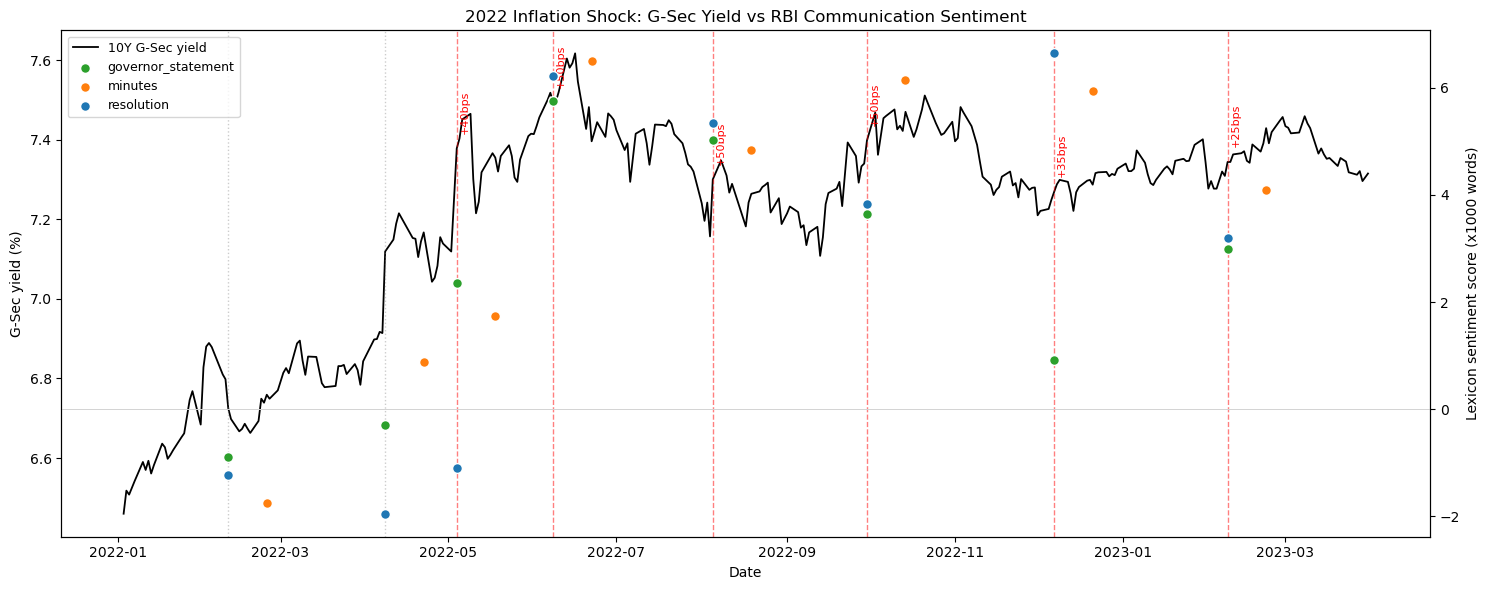

In [6]:
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(gsec_window.index, gsec_window.values, color="black", linewidth=1.3, label="10Y G-Sec yield", zorder=1)
ax1.set_ylabel("G-Sec yield (%)")
ax1.set_xlabel("Date")

for _, row in case_merged.iterrows():
    y_at_date = gsec_series.asof(row["listed_date"])
    if pd.notna(row["repo_rate_change_bps"]) and row["repo_rate_change_bps"] != 0:
        ax1.axvline(row["listed_date"], color="red", linestyle="--", alpha=0.5, linewidth=1)
        ax1.annotate(f"{int(row['repo_rate_change_bps']):+d}bps", (row["listed_date"], y_at_date),
                     textcoords="offset points", xytext=(2, 12), fontsize=8, color="red", rotation=90)
    else:
        ax1.axvline(row["listed_date"], color="gray", linestyle=":", alpha=0.4, linewidth=1)

ax2 = ax1.twinx()
colors = {"resolution": "tab:blue", "governor_statement": "tab:green", "minutes": "tab:orange"}
for dtype, grp in case_sentiment.groupby("doc_type"):
    ax2.scatter(grp["listed_date"], grp["lexicon_score_x1000"], label=dtype, color=colors.get(dtype, "black"), s=50, zorder=5, edgecolor="white")
ax2.axhline(0, color="lightgray", linewidth=0.7)
ax2.set_ylabel("Lexicon sentiment score (x1000 words)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.title("2022 Inflation Shock: G-Sec Yield vs RBI Communication Sentiment")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "case_study_2022.png", dpi=150)
plt.show()

---

**Result.** The April 8 meeting (no rate change) produced a 1-day yield move (+0.235pp) comparable to the actual emergency hike three weeks later (+0.284pp), and the yield rose 0.259pp in the interim between the two meetings. The lexicon sentiment score for the April 8 Resolution (−1.95) did not capture this shift; the Governor's Statement the same day scored closer to neutral (−0.29), and the Minutes published two weeks later scored clearly positive (+0.89) — consistent with the shift being an omission of dovish framing rather than an addition of hawkish language, which a word-count lexicon is structurally weaker at detecting.